# Asset Allocation Strategy Project

In [47]:
# !pip install yfinance #installing yfinance using !pip in ipynb
# # Terminal
# pip install yfinance

# # OR inside Jupyter notebook
# !pip install yfinance

# Terminal
# pip install PyPortfolioOpt

# Inside Jupyter notebook
# !pip install PyPortfolioOpt

# module used from above 
# from pypfopt import EfficientFrontier
# from pypfopt import risk_models, expected_returns


In [48]:
#importing the packages needed for this project

import yfinance as yf
import pandas as pd
import numpy as np
import scipy 
import matplotlib 
import seaborn as sb
import pypfopt

## Data Colection
- Used yfinance to pull historical price data for each selected stock 
- Calculate log return from daily prices - more statistically well-behaved than simple returns

In [ ]:
tickers = [
    #defensive and non-tech stocks
    'JNJ',   # Healthcare
    'KO',    # Consumer Staples
    'EOG',   # Energy
    'NEM',   # Gold / Commodities
    'ADM',   # Agriculture

    #large-cap tech stocks
    'MSFT',  # Cloud / AI / Software

    #mid-cap tech stocks
    'ADBE',  # Software
    'AMAT',  # Semiconductors

    #high growth tech stock
    'NVDA',  # AI Chips
]  #a list of 

#get 10 years of daily closing price data for the selected tickers
data = yf.download(tickers, start='2015-01-01', end='2025-01-01', threads = False)['Close'] #10 years

[                       0%                       ]

[*********************100%***********************]  9 of 9 completed


In [ ]:
#calculate log returns for each stock, which is a common way to compute returns in finance
log_returns = np.log(data / data.shift(1)).dropna() #drop any missing or na 

# save log returns into csv for phase 2
log_returns.to_csv('log_returns.csv')

## Porfolio Statistics
### Compute expected returns and the covariance matrix accross assets
### Derive portfolio-level return, volatility and sharp ratio (return per unit of risk)

In [112]:
#calculating the annualized expected returns 
mean_returns = log_returns.mean() * 252

print(f"Annualized Mean returns: \n{mean_returns}")

Annualized Mean returns: 
Ticker
ADBE    0.181959
ADM     0.025591
AMAT    0.200521
EOG     0.056421
JNJ     0.060192
KO      0.070970
MSFT    0.235581
NEM     0.088701
NVDA    0.563863
dtype: float64


In [53]:
#calculating the cov matrix
cov_matrix = log_returns.cov() * 252

#print out the covariance matrix
print("Covariance Matrix shape:", cov_matrix.shape) #9x9 matrix
print("Covariance Matrix:\n", cov_matrix) #print out the matrix

Covariance Matrix shape: (9, 9)
Covariance Matrix:
 Ticker      ADBE       ADM      AMAT       EOG       JNJ        KO      MSFT  \
Ticker                                                                         
ADBE    0.111180  0.022865  0.072497  0.029395  0.017091  0.018308  0.063957   
ADM     0.022865  0.073653  0.036514  0.045904  0.017750  0.020908  0.024617   
AMAT    0.072497  0.036514  0.163220  0.050868  0.018329  0.021176  0.065213   
EOG     0.029395  0.045904  0.050868  0.163244  0.015684  0.019551  0.029633   
JNJ     0.017091  0.017750  0.018329  0.015684  0.032672  0.016551  0.018778   
KO      0.018308  0.020908  0.021176  0.019551  0.016551  0.031917  0.019629   
MSFT    0.063957  0.024617  0.065213  0.029633  0.018778  0.019629  0.073608   
NEM     0.010327  0.014402  0.017344  0.023187  0.008630  0.011813  0.011574   
NVDA    0.091549  0.027997  0.126996  0.040164  0.015020  0.017171  0.079706   

Ticker       NEM      NVDA  
Ticker                      
ADBE    0

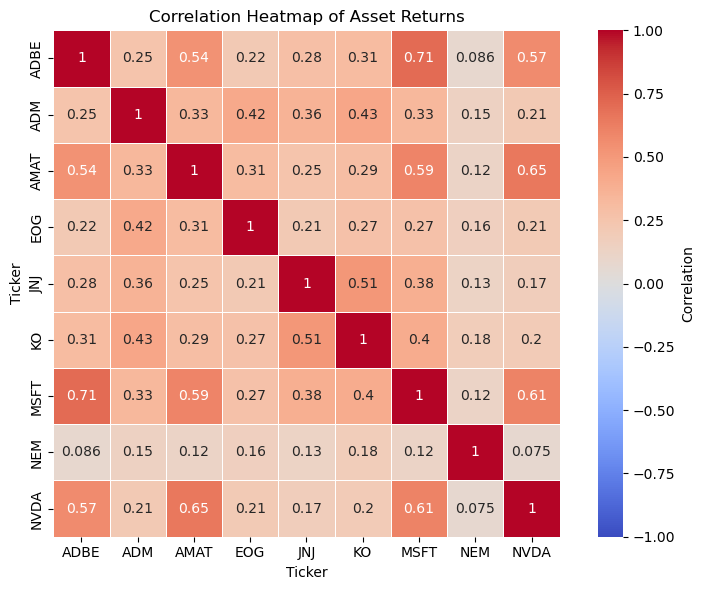

In [91]:
# Correlation matrix of assets
corr = log_returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Correlation Heatmap of Asset Returns')
plt.tight_layout()
plt.savefig('diversification_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [113]:
#define portfolio weights

def portfolio_stats(weights, mean_returns, cov_matrix, risk_free_rate=0.05):
    weights = np.array(weights)
    
    port_return = np.dot(weights, mean_returns)
    port_volatility = np.sqrt(weights.T @ cov_matrix @ weights)
    sharpe_ratio = (port_return - risk_free_rate) / port_volatility
    
    return port_return, port_volatility, sharpe_ratio


In [114]:
#monte carlo simulation to generate random portfolios and calculate their returns, volatility, and sharpe ratio
num_portfolios = 10000
num_assets = len(mean_returns)
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.dirichlet(np.ones(num_assets))  # sums to 1
    weights_record.append(weights)
    
    ret, vol, sharpe = portfolio_stats(weights, mean_returns, cov_matrix)
    results[0, i] = ret
    results[1, i] = vol
    results[2, i] = sharpe  # used for color coding


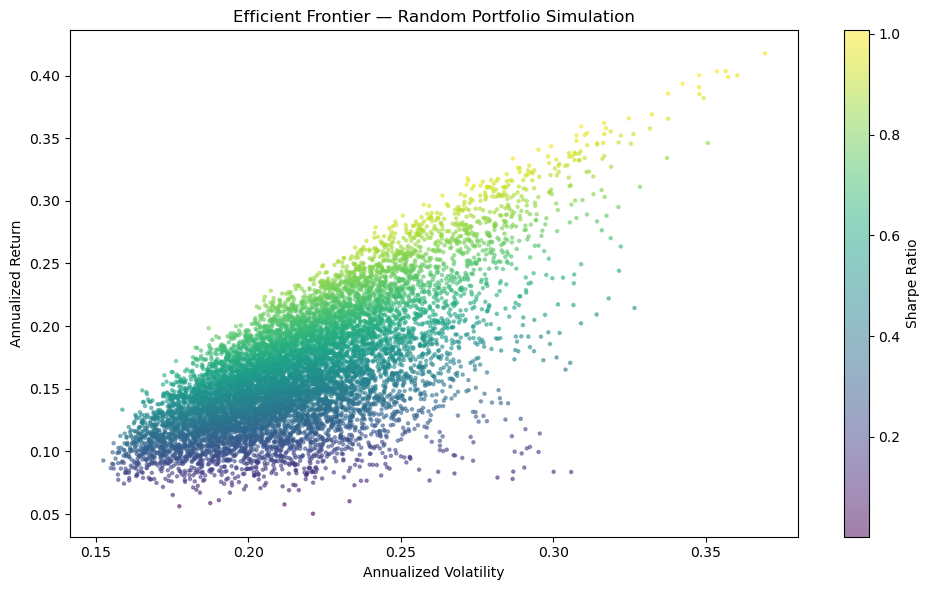

In [ ]:
#efficient frontier visualization using a scatter plot, with color representing the Sharpe ratio
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(results[1, :], results[0, :],
            c=results[2, :], cmap='viridis', alpha=0.5, s=5)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.title('Efficient Frontier — Random Portfolio Simulation')
plt.tight_layout()
plt.savefig('efficient_frontier_cloud.png')
plt.show()


In [ ]:
#save the mean returns and covariance matrix to csv
mean_returns.to_csv('mean_returns.csv')
cov_matrix.to_csv('cov_matrix.csv')


In [121]:

from pypfopt import EfficientFrontier, risk_models, expected_returns
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [122]:
# Re-download with auto_adjust and flatten columns
tickers = ['JNJ', 'KO', 'EOG', 'NEM', 'ADM', 'MSFT', 'ADBE', 'AMAT', 'NVDA']
raw = yf.download(tickers, start='2015-01-01', end='2025-01-01', auto_adjust=True)

# Flatten multi-level columns and extract Close
prices = raw['Close']
prices.columns = tickers  # explicitly rename to avoid any index weirdness
prices = prices.dropna()

print(prices.head())
print(prices.shape)


[*********************100%***********************]  9 of 9 completed

                  JNJ         KO        EOG        NEM        ADM       MSFT  \
Date                                                                           
2015-01-02  72.339996  37.381672  21.737469  66.832100  76.548607  29.783409   
2015-01-05  71.980003  36.088177  21.040749  62.803623  76.013969  29.783409   
2015-01-06  70.529999  35.376766  20.248240  61.013977  75.640480  30.009565   
2015-01-07  71.110001  35.908546  20.439837  60.629978  77.310310  30.384163   
2015-01-08  72.919998  35.383945  21.093004  62.948559  77.918167  30.751684   

                 ADBE       AMAT      NVDA  
Date                                        
2015-01-02  39.767693  15.070816  0.482985  
2015-01-05  39.401981  15.164321  0.474828  
2015-01-06  38.823662  15.795525  0.460432  
2015-01-07  39.316940  15.655253  0.459232  
2015-01-08  40.473587  15.569543  0.476507  
(2516, 9)


In [133]:
# ── Step 1: Recompute betas safely ─────────────────────────────────
spy = yf.download('SPY', start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
spy_returns = spy.pct_change().dropna()
stock_returns = prices.pct_change().dropna()

# Align dates
aligned_stock, aligned_spy = stock_returns.align(spy_returns, join='inner', axis=0)

# Compute beta for ALL tickers in prices
betas = {}
for ticker in aligned_stock.columns:
    cov = np.cov(aligned_stock[ticker], aligned_spy.squeeze())[0][1]
    var = np.var(aligned_spy.squeeze())
    betas[ticker] = cov / var

print("=== Individual Stock Betas ===")
print(pd.Series(betas).round(3))

# ── Step 2: Safe portfolio beta function ────────────────────────────
def compute_portfolio_beta(weights, betas):
    total_beta = 0
    for t, w in weights.items():
        if w > 0:
            if t in betas:
                total_beta += w * betas[t]
            else:
                print(f"Warning: {t} not found in betas, skipping")
    return total_beta

# ── Step 3: Compute beta for all three portfolios ───────────────────
beta_sharpe = compute_portfolio_beta(sharpe_weights, betas)
beta_minvol = compute_portfolio_beta(minvol_weights, betas)
beta_target = compute_portfolio_beta(target_weights, betas)

print(f"\nMax Sharpe Beta    : {beta_sharpe:.3f}")
print(f"Min Volatility Beta: {beta_minvol:.3f}")
print(f"20% Target Beta    : {beta_target:.3f}")


[*********************100%***********************]  1 of 1 completed

=== Individual Stock Betas ===
JNJ     1.293
KO      0.829
EOG     1.611
NEM     1.091
ADM     0.544
MSFT    0.595
ADBE    1.226
AMAT    0.393
NVDA    1.754
dtype: float64

Max Sharpe Beta    : 1.741
Min Volatility Beta: 0.629
20% Target Beta    : 0.793


In [134]:
#markowitz efficient frontier implementation from scratch using scipy.optimize.minimize

#implementing MVO from scratch using scipy
import numpy as np
from scipy.optimize import minimize

# Objective: minimize portfolio variance
def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

# Solve for minimum variance at a given target return
def markowitz_optimize(mean_returns, cov_matrix, target_return):
    n = len(mean_returns)
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},               # weights sum to 1
        {'type': 'eq', 'fun': lambda w: w @ mean_returns - target_return}  # hit target return
    ]
    bounds = [(0, 1) for _ in range(n)]   # no short selling
    result = minimize(portfolio_variance, x0=np.ones(n)/n,
                      args=(cov_matrix,), method='SLSQP',
                      bounds=bounds, constraints=constraints)
    return result.x

# Sweep target returns to trace the full frontier
target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 100)
frontier_weights = [markowitz_optimize(mean_returns, cov_matrix, r) for r in target_returns]
frontier_vols = [np.sqrt(w @ cov_matrix @ w) for w in frontier_weights]

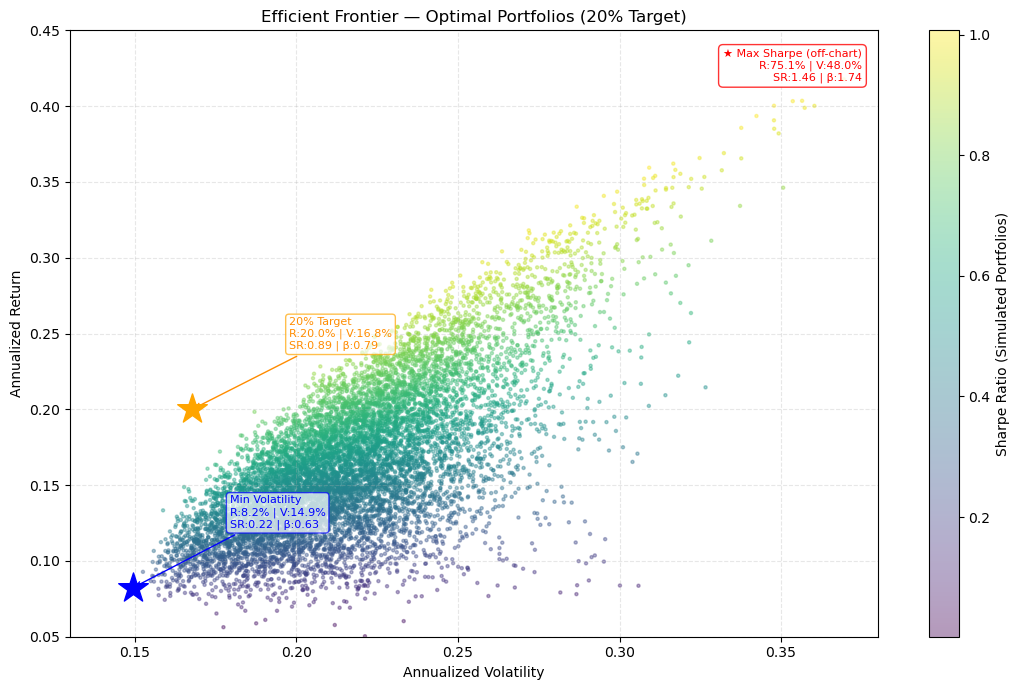

In [ ]:
#efficient frontier visualization with optimal portfolios highlighted
fig, ax = plt.subplots(figsize=(11, 7))

# ── Background simulation cloud ─────────────────────────────────────
sc = ax.scatter(results[1, :], results[0, :],
                c=results[2, :], cmap='viridis', alpha=0.4, s=5)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Sharpe Ratio (Simulated Portfolios)')

# ── Clip to meaningful region ───────────────────────────────────────
ax.set_xlim(0.13, 0.38)
ax.set_ylim(0.05, 0.45)

# ── Min Volatility star (blue) ──────────────────────────────────────
ax.scatter(vol2, ret2, marker='*', s=500, color='blue', zorder=5)
ax.annotate(f'Min Volatility\nR:{ret2:.1%} | V:{vol2:.1%}\nSR:{sharpe2:.2f} | β:{beta_minvol:.2f}',
            xy=(vol2, ret2),
            xytext=(vol2 + 0.03, ret2 + 0.04),
            fontsize=8, color='blue',
            arrowprops=dict(arrowstyle='->', color='blue'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='blue', alpha=0.7))

# ── 20% Target star (orange) ────────────────────────────────────────
ax.scatter(vol3, ret3, marker='*', s=500, color='orange', zorder=5)
ax.annotate(f'20% Target\nR:{ret3:.1%} | V:{vol3:.1%}\nSR:{sharpe3:.2f} | β:{beta_target:.2f}',
            xy=(vol3, ret3),
            xytext=(vol3 + 0.03, ret3 + 0.04),
            fontsize=8, color='darkorange',
            arrowprops=dict(arrowstyle='->', color='darkorange'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='orange', alpha=0.7))

# ── Max Sharpe off-chart text box (red) ─────────────────────────────
ax.text(0.98, 0.97,
        f'★ Max Sharpe (off-chart)\nR:{ret:.1%} | V:{vol:.1%}\nSR:{sharpe:.2f} | β:{beta_sharpe:.2f}',
        transform=ax.transAxes, fontsize=8, color='red',
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='red', alpha=0.8))

# ── Labels & formatting ─────────────────────────────────────────────
ax.set_xlabel('Annualized Volatility')
ax.set_ylabel('Annualized Return')
ax.set_title('Efficient Frontier — Optimal Portfolios (20% Target)')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('efficient_frontier_optimal.png', dpi=150)
plt.show()


In [ ]:
#weight tables for the three optimal portfolios, saved as CSV and printed as a table
import pandas as pd

# ── Build weights DataFrame ─────────────────────────────────────────
weights_df = pd.DataFrame({
    'Max Sharpe':     sharpe_weights,
    'Min Volatility': minvol_weights,
    '20% Target':     target_weights
})

# ── Convert to percentages ──────────────────────────────────────────
weights_pct = (weights_df * 100).round(2)
weights_pct.index.name = 'Ticker'

# ── Add a Total row to verify all sum to 100% ───────────────────────
weights_pct.loc['TOTAL'] = weights_pct.sum()

print("=== Portfolio Weights (%) ===")
print(weights_pct.to_string())

# ── Save as CSV ─────────────────────────────────────────────────────
weights_pct.to_csv('portfolio_weights.csv')
print("\nSaved to portfolio_weights.csv")


=== Portfolio Weights (%) ===
        Max Sharpe  Min Volatility  20% Target
Ticker                                        
JNJ           0.00            3.59        0.00
KO            0.00            5.64        0.00
EOG           0.00            0.00        0.00
NEM           0.00            1.76        0.00
ADM           0.00           38.47       32.93
MSFT          0.00           37.10       34.39
ADBE          0.00            3.20        5.57
AMAT          0.96            9.72        9.91
NVDA         99.04            0.52       17.20
TOTAL       100.00          100.00      100.00

Saved to portfolio_weights.csv


C:\Users\User\AppData\Local\Temp\ipykernel_21692\748311237.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  table_data = weights_pct.applymap(lambda x: f"{x:.2f}%")


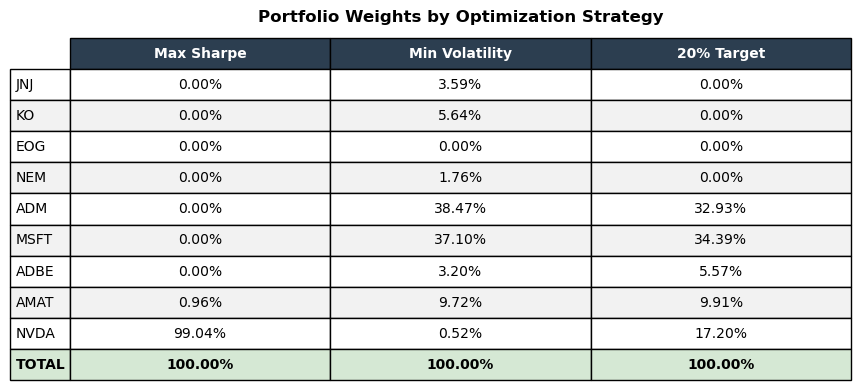

Saved to portfolio_weights_table.png


In [ ]:
# ── Visualize as a Table ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd

# ── Build clean weights table ───────────────────────────────────────
weights_df = pd.DataFrame({
    'Max Sharpe':     sharpe_weights,
    'Min Volatility': minvol_weights,
    '20% Target':     target_weights
})
weights_pct = (weights_df * 100).round(2)
weights_pct.loc['TOTAL'] = weights_pct.sum()

# ── Format values as strings with % ────────────────────────────────
table_data = weights_pct.applymap(lambda x: f"{x:.2f}%")

# ── Plot as table ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')

table = ax.table(
    cellText=table_data.values,
    rowLabels=table_data.index,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 1.8)

# ── Style header row & total row ────────────────────────────────────
for (row, col), cell in table.get_celld().items():
    if row == 0:  # header
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif table_data.index[row - 1] == 'TOTAL':  # total row
        cell.set_facecolor('#d5e8d4')
        cell.set_text_props(fontweight='bold')
    elif row % 2 == 0:  # alternating row colors
        cell.set_facecolor('#f2f2f2')
    else:
        cell.set_facecolor('white')

plt.title('Portfolio Weights by Optimization Strategy', 
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('portfolio_weights_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to portfolio_weights_table.png")


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Load prices (already downloaded, just reuse)
# prices is already in memory — if not, re-download:
# tickers = ['JNJ','KO','EOG','NEM','ADM','MSFT','ADBE','AMAT','NVDA']
# prices = yf.download(tickers, start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
# prices.columns = tickers

# Daily returns
returns = prices.pct_change().dropna()


In [135]:
def portfolio_daily_returns(weights, returns):
    w = pd.Series(weights)
    w = w[w > 0]  # drop zero weights
    return (returns[w.index] * w).sum(axis=1)

ret_sharpe  = portfolio_daily_returns(sharpe_weights,  returns)
ret_minvol  = portfolio_daily_returns(minvol_weights,  returns)
ret_target  = portfolio_daily_returns(target_weights,  returns)

# SPY benchmark
spy = yf.download('SPY', start='2015-01-01', end='2025-01-01', 
                  auto_adjust=True)['Close']
ret_spy = spy.pct_change().dropna().squeeze()

# Align all to same dates
all_returns = pd.DataFrame({
    'Max Sharpe':     ret_sharpe,
    'Min Volatility': ret_minvol,
    '20% Target':     ret_target,
    'SPY Benchmark':  ret_spy
}).dropna()


[*********************100%***********************]  1 of 1 completed


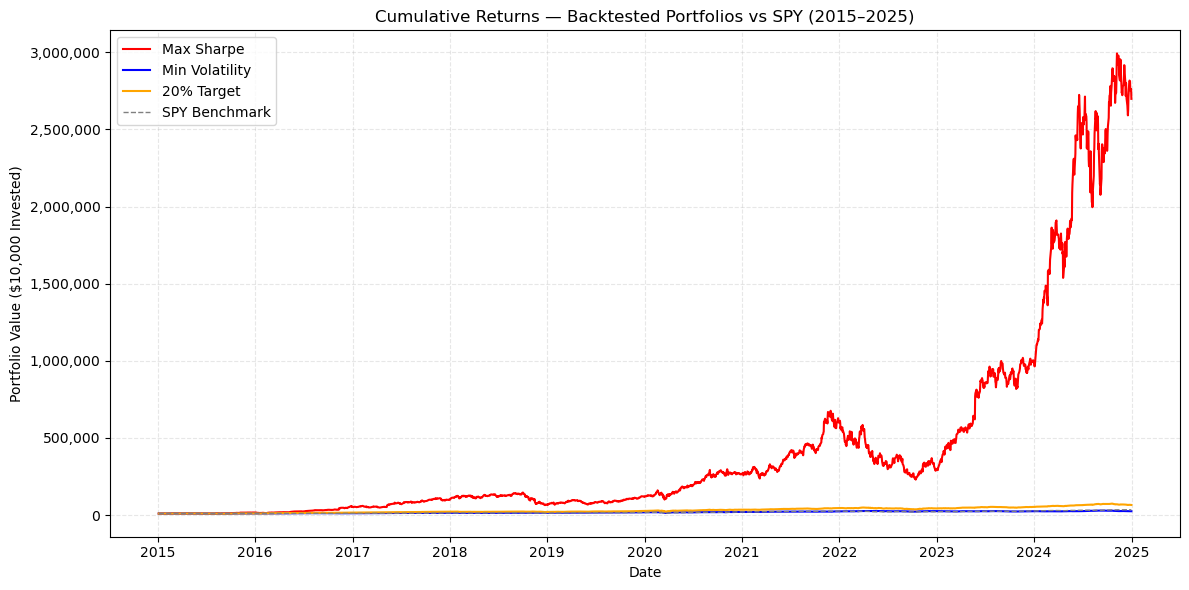

In [ ]:
#cumulative returns starting from $10,000 invested for all portfolios and the SPY benchmark
cumulative = 10000* (1 + all_returns).cumprod()

import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red', 'blue', 'orange', 'grey']

for col, color in zip(cumulative.columns, colors):
    ax.plot(cumulative.index, cumulative[col], label=col, color=color,
            linewidth=1.5 if col != 'SPY Benchmark' else 1,
            linestyle='--' if col == 'SPY Benchmark' else '-')

ax.set_title('Cumulative Returns — Backtested Portfolios vs SPY (2015–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($10,000 Invested)')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('backtest_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()



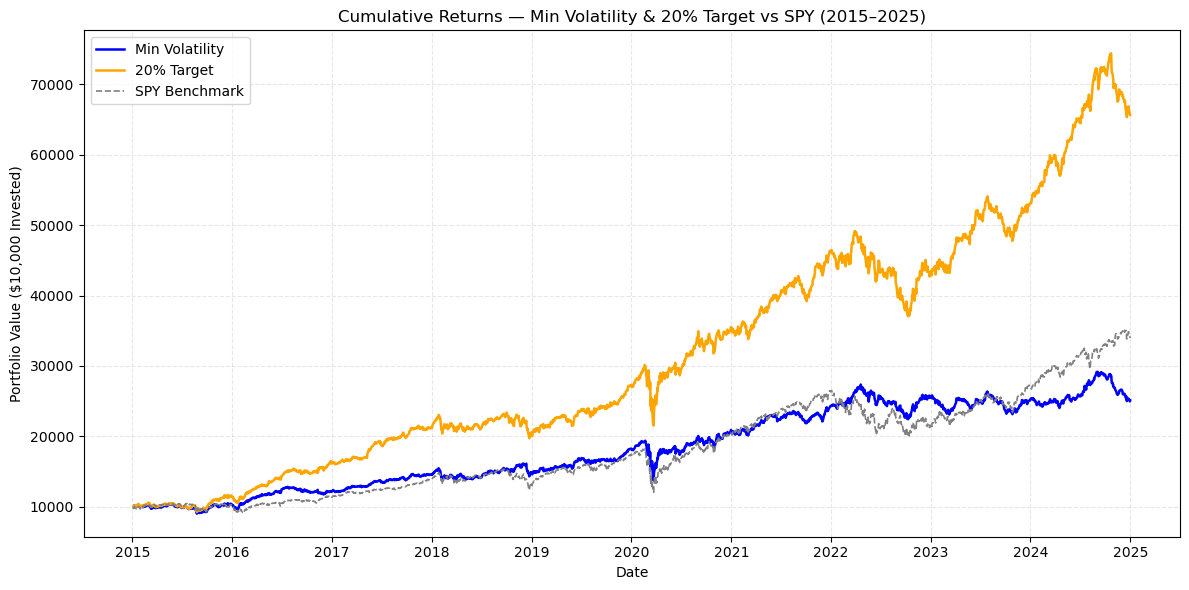

In [ ]:
#cumulative returns starting from 0% for all portfolios and the SPY benchmark, to show pure return growth without scaling to an initial investment
cumulative = (1 + all_returns).cumprod()

initial_investment = 10000
cumulative = (1 + all_returns).cumprod() * initial_investment

fig, ax = plt.subplots(figsize=(12, 6))

# Plot only the three lines you want on this chart
colors = ['blue', 'orange', 'grey']
linestyles = ['-', '-', '--']
linewidths = [1.8, 1.8, 1.2]
columns = ['Min Volatility', '20% Target', 'SPY Benchmark']

for col, color, ls, lw in zip(columns, colors, linestyles, linewidths):
    ax.plot(cumulative.index, cumulative[col], label=col, color=color, 
            linestyle=ls, linewidth=lw)

ax.set_title('Cumulative Returns — Min Volatility & 20% Target vs SPY (2015–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($10,000 Invested)')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('backtest_cumulative_returns_no_maxsharpe.png', dpi=150, bbox_inches='tight')
plt.show()


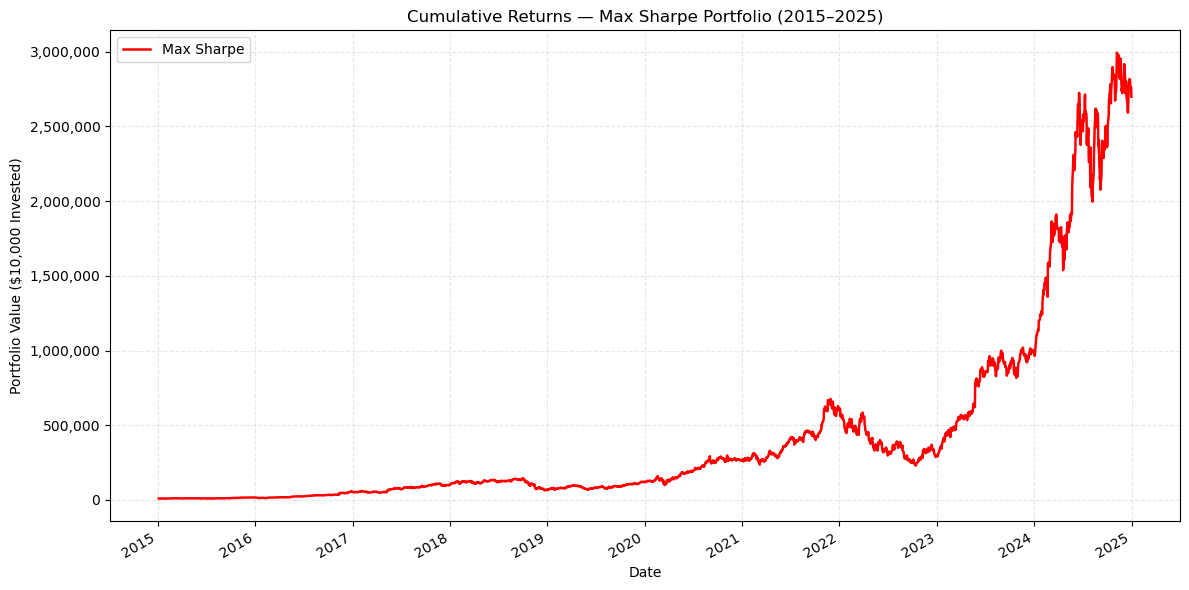

In [ ]:
#cumulative returns starting from 0% for the Max Sharpe portfolio only, to show pure return growth without scaling to an initial investment
import matplotlib.ticker as mtick

# after you create ax and plot the line
fig, ax = plt.subplots(figsize=(12, 6))

cumulative_10k[['Max Sharpe']].plot(
    ax=ax,
    color='red',
    linewidth=1.8,
)

ax.set_title('Cumulative Returns — Max Sharpe Portfolio (2015–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($10,000 Invested)')

# ↓ key line: disable scientific notation on y-axis
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig('backtest_cumulative_returns_maxsharpe_only.png', dpi=150, bbox_inches='tight')
plt.show()


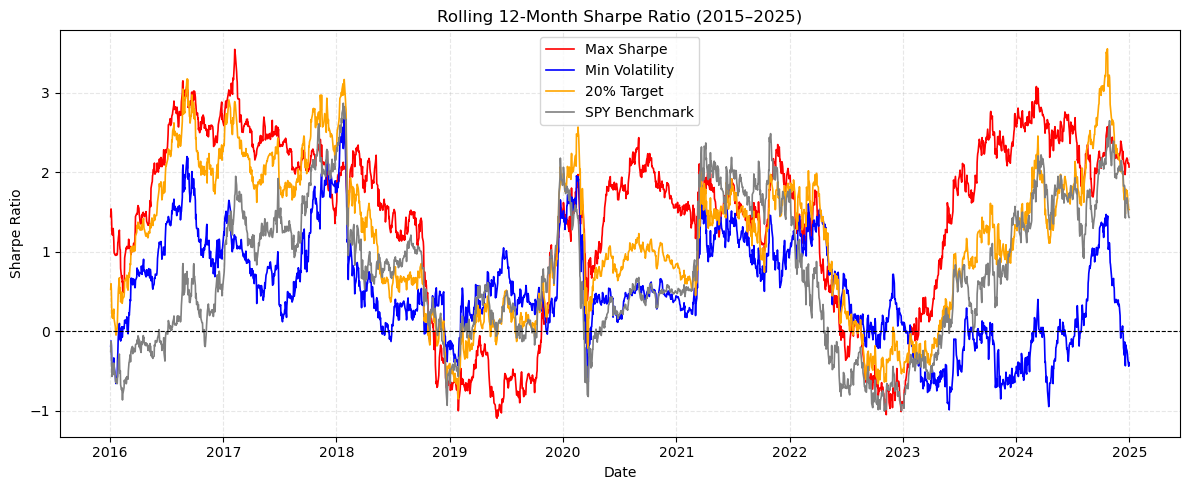

In [143]:
rolling_sharpe = all_returns.rolling(252).apply(
    lambda x: (x.mean() * 252 - 0.05) / (x.std() * np.sqrt(252))
)

fig, ax = plt.subplots(figsize=(12, 5))
for col, color in zip(rolling_sharpe.columns, colors):
    ax.plot(rolling_sharpe.index, rolling_sharpe[col], label=col, 
            color=color, linewidth=1.2)

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Rolling 12-Month Sharpe Ratio (2015–2025)')
ax.set_xlabel('Date')
ax.set_ylabel('Sharpe Ratio')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('backtest_rolling_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()


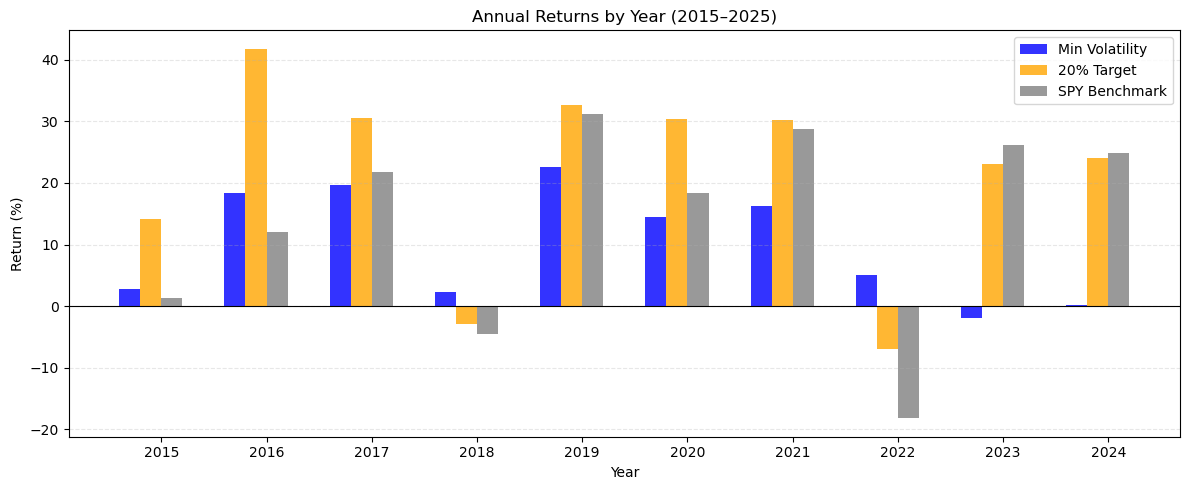

In [ ]:
# compute annual returns if not already defined
try:
    annual_returns
except NameError:
    annual_returns = all_returns.resample('YE').apply(
        lambda x: (1 + x).prod() - 1
    ) * 100

annual_returns_plot = annual_returns.drop(columns=['Max Sharpe'])

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(annual_returns_plot))
width = 0.2

for i, (col, color) in enumerate(zip(annual_returns_plot.columns, colors)):
    ax.bar(x + i * width, annual_returns_plot[col], width,
           label=col, color=color, alpha=0.8)

ax.set_title('Annual Returns by Year (2015–2025)')
ax.set_xlabel('Year')
ax.set_ylabel('Return (%)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(annual_returns_plot.index.year)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('backtest_annual_returns.png', dpi=150, bbox_inches='tight')
plt.show()


=== Phase 4 Performance Summary ===
                Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  Max Drawdown (%)  Total Return (%)  Portfolio Beta
Max Sharpe                67.62                48.17         1.300            -65.99      2.698349e+08           1.741
Min Volatility            10.33                14.89         0.358            -29.23      2.510188e+06           0.629
20% Target                20.27                16.77         0.911            -28.51      6.567471e+06           0.793
SPY Benchmark             13.81                17.62         0.500            -33.72      3.395636e+06           1.000


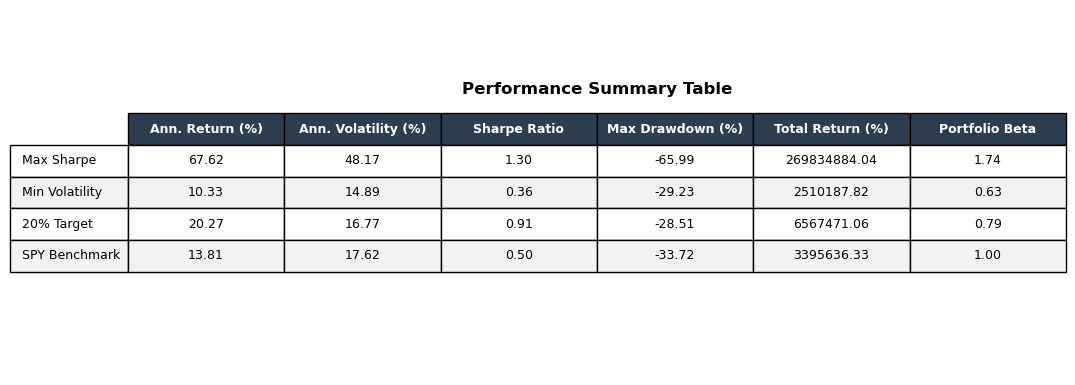

Saved to backtest_summary_table.png


In [161]:
#combine all the performance metrics into a summary table, including annualized return, volatility, Sharpe ratio, max drawdown, total return, and portfolio beta
def max_drawdown(cum_returns):
    rolling_max = cum_returns.cummax()
    drawdown = (cum_returns - rolling_max) / rolling_max
    return drawdown.min()

# existing summary
summary = pd.DataFrame({
    'Ann. Return (%)':    (all_returns.mean() * 252 * 100).round(2),
    'Ann. Volatility (%)': (all_returns.std() * np.sqrt(252) * 100).round(2),
    'Sharpe Ratio':       ((all_returns.mean() * 252 - 0.05) /
                           (all_returns.std() * np.sqrt(252))).round(3),
    'Max Drawdown (%)':   (cumulative.apply(max_drawdown) * 100).round(2),
    'Total Return (%)':   ((cumulative.iloc[-1] - 1) * 100).round(2)
})

# portfolio betas you already have
beta_series = pd.Series({
    'Max Sharpe':     beta_sharpe,
    'Min Volatility': beta_minvol,
    '20% Target':     beta_target,
    'SPY Benchmark':  1.0,   # by definition vs itself
}).round(3)

summary['Portfolio Beta'] = beta_series

print("=== Phase 4 Performance Summary ===")
print(summary.to_string())
summary.to_csv('backtest_summary.csv')

# ── Print formatted table ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.axis('off')

# Format numeric values
table_data = summary.apply(lambda x: x.apply(lambda v: f"{v:.2f}" if isinstance(v, (int, float)) else str(v)))

table = ax.table(
    cellText=table_data.values,
    rowLabels=table_data.index,
    colLabels=table_data.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2.0)

# ── Style header row ────────────────────────────────────────────────
for (row, col), cell in table.get_celld().items():
    if row == 0:  # header
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:  # alternating row colors
        cell.set_facecolor('#f2f2f2')
    else:
        cell.set_facecolor('white')

plt.title('Performance Summary Table', 
          fontsize=12, fontweight='bold', pad=0, y=0.77)
# tighten layout and push top margin down further to snug title against table
plt.tight_layout()
fig.subplots_adjust(top=0.76)
plt.savefig('backtest_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to backtest_summary_table.png")
